# Brain MRI Segmentation - Classical Algorithms
**Dataset:** LGG Brain MRI Segmentation (mateuszbuda/lgg-mri-segmentation)

**Implemented Algorithms:**
- Otsu Thresholding
- K-means Clustering
- Canny Edge Detection + post-processing

**Evaluation Metrics:**
- Dice Coefficient
- IoU (Jaccard Index)
- Precision, Recall, F1-score, Accuracy

## 1. Install & Import Libraries

In [1]:
# Install required libraries (uncomment if needed)
# !pip install opencv-python scikit-image scikit-learn matplotlib numpy pandas tqdm

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
from glob import glob
from skimage import filters, morphology, measure
from sklearn.cluster import KMeans
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Display settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load Dataset

In [3]:
# --------------------------------
# Set your dataset path here
# If running on Kaggle:
DATASET_PATH = "C:\\Users\\amazonshop\\Desktop\\tumor_detector\\kaggle_3m"
# If running locally:
# DATASET_PATH = 'kaggle_3m'  # path to the unzipped dataset folder
# --------------------------------

# Find all MRI images (exclude masks)
all_image_paths = sorted([
    p for p in glob(os.path.join(DATASET_PATH, '**', '*.tif'), recursive=True)
    if '_mask' not in p
])

# Find the corresponding mask for each image
all_mask_paths = [p.replace('.tif', '_mask.tif') for p in all_image_paths]

# Keep only pairs where both image and mask exist
valid_pairs = [
    (img, msk) for img, msk in zip(all_image_paths, all_mask_paths)
    if os.path.exists(msk)
]

print(f'📁 Total valid image-mask pairs: {len(valid_pairs)}')

# Keep only images that actually contain a tumor (non-zero mask)
tumor_pairs = []
for img_path, msk_path in valid_pairs:
    mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    if mask is not None and mask.max() > 0:
        tumor_pairs.append((img_path, msk_path))

print(f'🧠 Images with tumor: {len(tumor_pairs)}')

# Randomly select N samples for faster evaluation
N_SAMPLES = 50  # increase this for more thorough evaluation
np.random.seed(42)
selected_pairs = [tumor_pairs[i] for i in np.random.choice(len(tumor_pairs), min(N_SAMPLES, len(tumor_pairs)), replace=False)]
print(f'🎯 Selected samples for evaluation: {len(selected_pairs)}')

📁 Total valid image-mask pairs: 3929
🧠 Images with tumor: 1373
🎯 Selected samples for evaluation: 50


## 3. Preprocessing

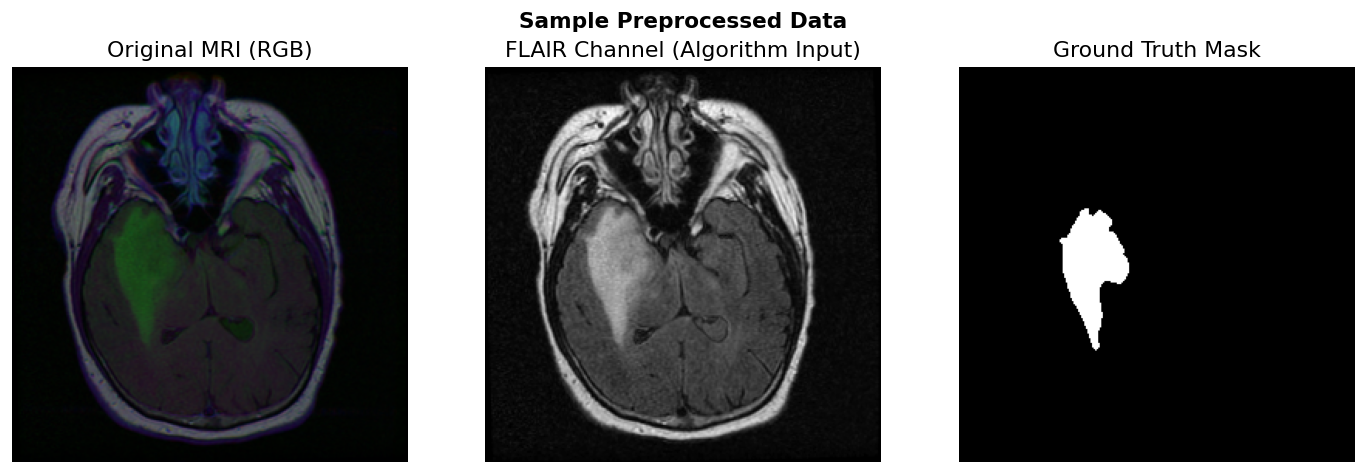

✅ Preprocessing successful


In [4]:
IMG_SIZE = 256  # standard image size for all algorithms

def preprocess_image(img_path, size=IMG_SIZE):
    """Load and preprocess an MRI image."""
    # Load the .tif image (3 channels: pre-contrast, FLAIR, post-contrast)
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    
    # Resize to standard dimensions
    img = cv2.resize(img, (size, size))
    
    # Extract the FLAIR channel (channel index 1 = green channel)
    # FLAIR is best for tumor visibility: tumors appear brighter
    flair = img[:, :, 1]
    
    # Normalize pixel values to [0, 255]
    flair_norm = cv2.normalize(flair, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return img, flair_norm

def preprocess_mask(msk_path, size=IMG_SIZE):
    """Load and preprocess a ground truth mask."""
    mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    # Resize using nearest-neighbor to preserve binary values
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    # Binarize: 0 = background, 1 = tumor
    mask = (mask > 127).astype(np.uint8)
    return mask

# Test preprocessing on one sample
test_img, test_flair = preprocess_image(selected_pairs[0][0])
test_mask = preprocess_mask(selected_pairs[0][1])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original MRI (RGB)')
axes[0].axis('off')
axes[1].imshow(test_flair, cmap='gray')
axes[1].set_title('FLAIR Channel (Algorithm Input)')
axes[1].axis('off')
axes[2].imshow(test_mask, cmap='gray')
axes[2].set_title('Ground Truth Mask')
axes[2].axis('off')
plt.suptitle('Sample Preprocessed Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Preprocessing successful')

## 4. Algorithm Implementations

### 4.1 Algorithm 1: Otsu Thresholding

In [5]:
def segment_otsu(flair_img):
    """
    Otsu Thresholding:
    - Automatically finds the optimal threshold from the image histogram
    - Maximizes inter-class variance between tumor and non-tumor pixels
    """
    # Gaussian blur to reduce noise before thresholding
    blurred = cv2.GaussianBlur(flair_img, (5, 5), 0)
    
    # Apply Otsu's automatic thresholding
    thresh_val, binary = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # Post-processing with morphological operations to clean up the mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)   # remove small noise spots
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)  # fill small holes
    
    # Keep only the largest connected component (most likely the tumor region)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    if num_labels > 1:
        # Find largest component excluding background (label 0)
        largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        result = (labels == largest).astype(np.uint8)
    else:
        result = (cleaned > 0).astype(np.uint8)
    
    return result, thresh_val

# Test
otsu_result, thresh_val = segment_otsu(test_flair)
print(f'✅ Otsu - threshold value: {thresh_val:.1f}')
print(f'   Tumor pixels: {otsu_result.sum()} out of {otsu_result.size}')

✅ Otsu - threshold value: 84.0
   Tumor pixels: 6551 out of 65536


### 4.2 Algorithm 2: K-means Clustering

In [6]:
def segment_kmeans(flair_img, k=3):
    """
    K-means Clustering:
    - Groups pixels into k clusters based on intensity values
    - The brightest cluster is selected as the tumor region
      (tumors appear hyperintense in FLAIR sequences)
    """
    # Flatten image into a 1D array of pixel intensities
    pixels = flair_img.reshape(-1, 1).astype(np.float32)
    
    # Run K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    
    # Reshape back to image dimensions
    segmented = labels.reshape(flair_img.shape)
    
    # Find the cluster with the highest mean intensity (= tumor)
    cluster_means = [flair_img[segmented == i].mean() for i in range(k)]
    tumor_cluster = np.argmax(cluster_means)
    
    # Create binary tumor mask
    binary = (segmented == tumor_cluster).astype(np.uint8)
    
    # Post-processing: morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    
    # Keep only the largest connected region
    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    if num_labels > 1:
        largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        result = (labels_cc == largest).astype(np.uint8)
    else:
        result = cleaned
    
    return result, cluster_means

# Test
kmeans_result, cluster_means = segment_kmeans(test_flair, k=3)
print(f'✅ K-means - cluster mean intensities: {[f"{m:.1f}" for m in cluster_means]}')
print(f'   Tumor pixels: {kmeans_result.sum()} out of {kmeans_result.size}')

✅ K-means - cluster mean intensities: ['11.4', '165.9', '69.8']
   Tumor pixels: 1952 out of 65536


### 4.3 Algorithm 3: Canny Edge Detection + Post-processing

In [7]:
def segment_canny(flair_img):
    """
    Canny Edge Detection + Post-processing:
    - Detects the boundaries of the tumor region
    - Uses flood fill to create a solid mask from detected edges
    """
    # Blur to reduce noise before edge detection
    blurred = cv2.GaussianBlur(flair_img, (7, 7), 1.5)
    
    # Adaptive Canny thresholds based on image median intensity
    median_val = np.median(blurred)
    lower = int(max(0, 0.5 * median_val))
    upper = int(min(255, 1.5 * median_val))
    edges = cv2.Canny(blurred, lower, upper)
    
    # Dilate edges to close small gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    dilated = cv2.dilate(edges, kernel, iterations=2)
    
    # Flood fill from corner to identify interior regions
    filled = dilated.copy()
    h, w = filled.shape
    flood_mask = np.zeros((h+2, w+2), np.uint8)
    cv2.floodFill(filled, flood_mask, (0, 0), 255)
    filled_inv = cv2.bitwise_not(filled)
    result_raw = cv2.bitwise_or(dilated, filled_inv)
    
    # Restrict to bright regions only (tumors are hyperintense in FLAIR)
    bright_mask = (flair_img > np.percentile(flair_img, 75)).astype(np.uint8) * 255
    combined = cv2.bitwise_and(result_raw, bright_mask)
    
    # Morphological cleanup
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    cleaned = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel2)
    
    # Keep only the largest connected region
    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    if num_labels > 1:
        largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        result = (labels_cc == largest).astype(np.uint8)
    else:
        result = (cleaned > 0).astype(np.uint8)
    
    return result, edges

# Test
canny_result, edges_raw = segment_canny(test_flair)
print(f'✅ Canny - tumor pixels: {canny_result.sum()} out of {canny_result.size}')

✅ Canny - tumor pixels: 3124 out of 65536


## 5. Evaluation Metrics

In [8]:
def compute_metrics(pred_mask, gt_mask):
    """
    Compute all standard segmentation evaluation metrics.
    
    Args:
        pred_mask : predicted binary mask (0 or 1)
        gt_mask   : ground truth binary mask (0 or 1)
    Returns:
        dict with Dice, IoU, Precision, Recall, F1, Accuracy
    """
    pred_flat = pred_mask.flatten()
    gt_flat   = gt_mask.flatten()
    
    # Compute confusion matrix components
    TP = np.logical_and(pred_flat == 1, gt_flat == 1).sum()
    FP = np.logical_and(pred_flat == 1, gt_flat == 0).sum()
    FN = np.logical_and(pred_flat == 0, gt_flat == 1).sum()
    TN = np.logical_and(pred_flat == 0, gt_flat == 0).sum()
    
    # Dice Coefficient = 2*TP / (2*TP + FP + FN)
    dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    
    # IoU / Jaccard Index = TP / (TP + FP + FN)
    iou = TP / (TP + FP + FN + 1e-8)
    
    # Precision = TP / (TP + FP)
    precision = TP / (TP + FP + 1e-8)
    
    # Recall (Sensitivity) = TP / (TP + FN)
    recall = TP / (TP + FN + 1e-8)
    
    # F1-score = harmonic mean of Precision and Recall
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    
    # Accuracy = (TP + TN) / Total pixels
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    
    return {
        'Dice':      round(dice, 4),
        'IoU':       round(iou, 4),
        'Precision': round(precision, 4),
        'Recall':    round(recall, 4),
        'F1':        round(f1, 4),
        'Accuracy':  round(accuracy, 4)
    }

# Test metrics on one sample
print('📊 Metrics on test sample:')
print('\nOtsu:')
print(compute_metrics(otsu_result, test_mask))
print('\nK-means:')
print(compute_metrics(kmeans_result, test_mask))
print('\nCanny:')
print(compute_metrics(canny_result, test_mask))

📊 Metrics on test sample:

Otsu:
{'Dice': np.float64(0.4896), 'IoU': np.float64(0.3242), 'Precision': np.float64(0.3248), 'Recall': np.float64(0.9939), 'F1': np.float64(0.4896), 'Accuracy': np.float64(0.9323)}

K-means:
{'Dice': np.float64(0.9118), 'IoU': np.float64(0.8379), 'Precision': np.float64(0.9559), 'Recall': np.float64(0.8716), 'F1': np.float64(0.9118), 'Accuracy': np.float64(0.9945)}

Canny:
{'Dice': np.float64(0.8122), 'IoU': np.float64(0.6837), 'Precision': np.float64(0.6844), 'Recall': np.float64(0.9986), 'F1': np.float64(0.8122), 'Accuracy': np.float64(0.9849)}


## 6. Run on All Samples & Compute Average Metrics

In [9]:
results = {'Otsu': [], 'KMeans': [], 'Canny': []}

print(f'🔄 Processing {len(selected_pairs)} images...')

for img_path, msk_path in tqdm(selected_pairs):
    # Preprocess image and mask
    _, flair = preprocess_image(img_path)
    gt_mask  = preprocess_mask(msk_path)
    
    if flair is None or gt_mask is None:
        continue
    
    # Run all three algorithms
    otsu_pred,   _ = segment_otsu(flair)
    kmeans_pred, _ = segment_kmeans(flair, k=3)
    canny_pred,  _ = segment_canny(flair)
    
    # Evaluate each prediction against ground truth
    results['Otsu'].append(compute_metrics(otsu_pred,   gt_mask))
    results['KMeans'].append(compute_metrics(kmeans_pred, gt_mask))
    results['Canny'].append(compute_metrics(canny_pred,  gt_mask))

print('\n✅ Processing complete!')

# Build summary table with average metrics across all samples
metrics_list = ['Dice', 'IoU', 'Precision', 'Recall', 'F1', 'Accuracy']
summary = {}
for algo, res_list in results.items():
    summary[algo] = {m: round(np.mean([r[m] for r in res_list]), 4) for m in metrics_list}

df_results = pd.DataFrame(summary).T
print('\n📊 Average metrics across all samples:')
print(df_results.to_string())

🔄 Processing 50 images...


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:16<00:00,  3.11it/s]


✅ Processing complete!

📊 Average metrics across all samples:
          Dice     IoU  Precision  Recall      F1  Accuracy
Otsu    0.1601  0.0922     0.0925  0.8928  0.1601    0.7194
KMeans  0.3254  0.2791     0.3958  0.2954  0.3254    0.9675
Canny   0.3100  0.2204     0.2241  0.8318  0.3100    0.8777


## 7. Visual Comparison

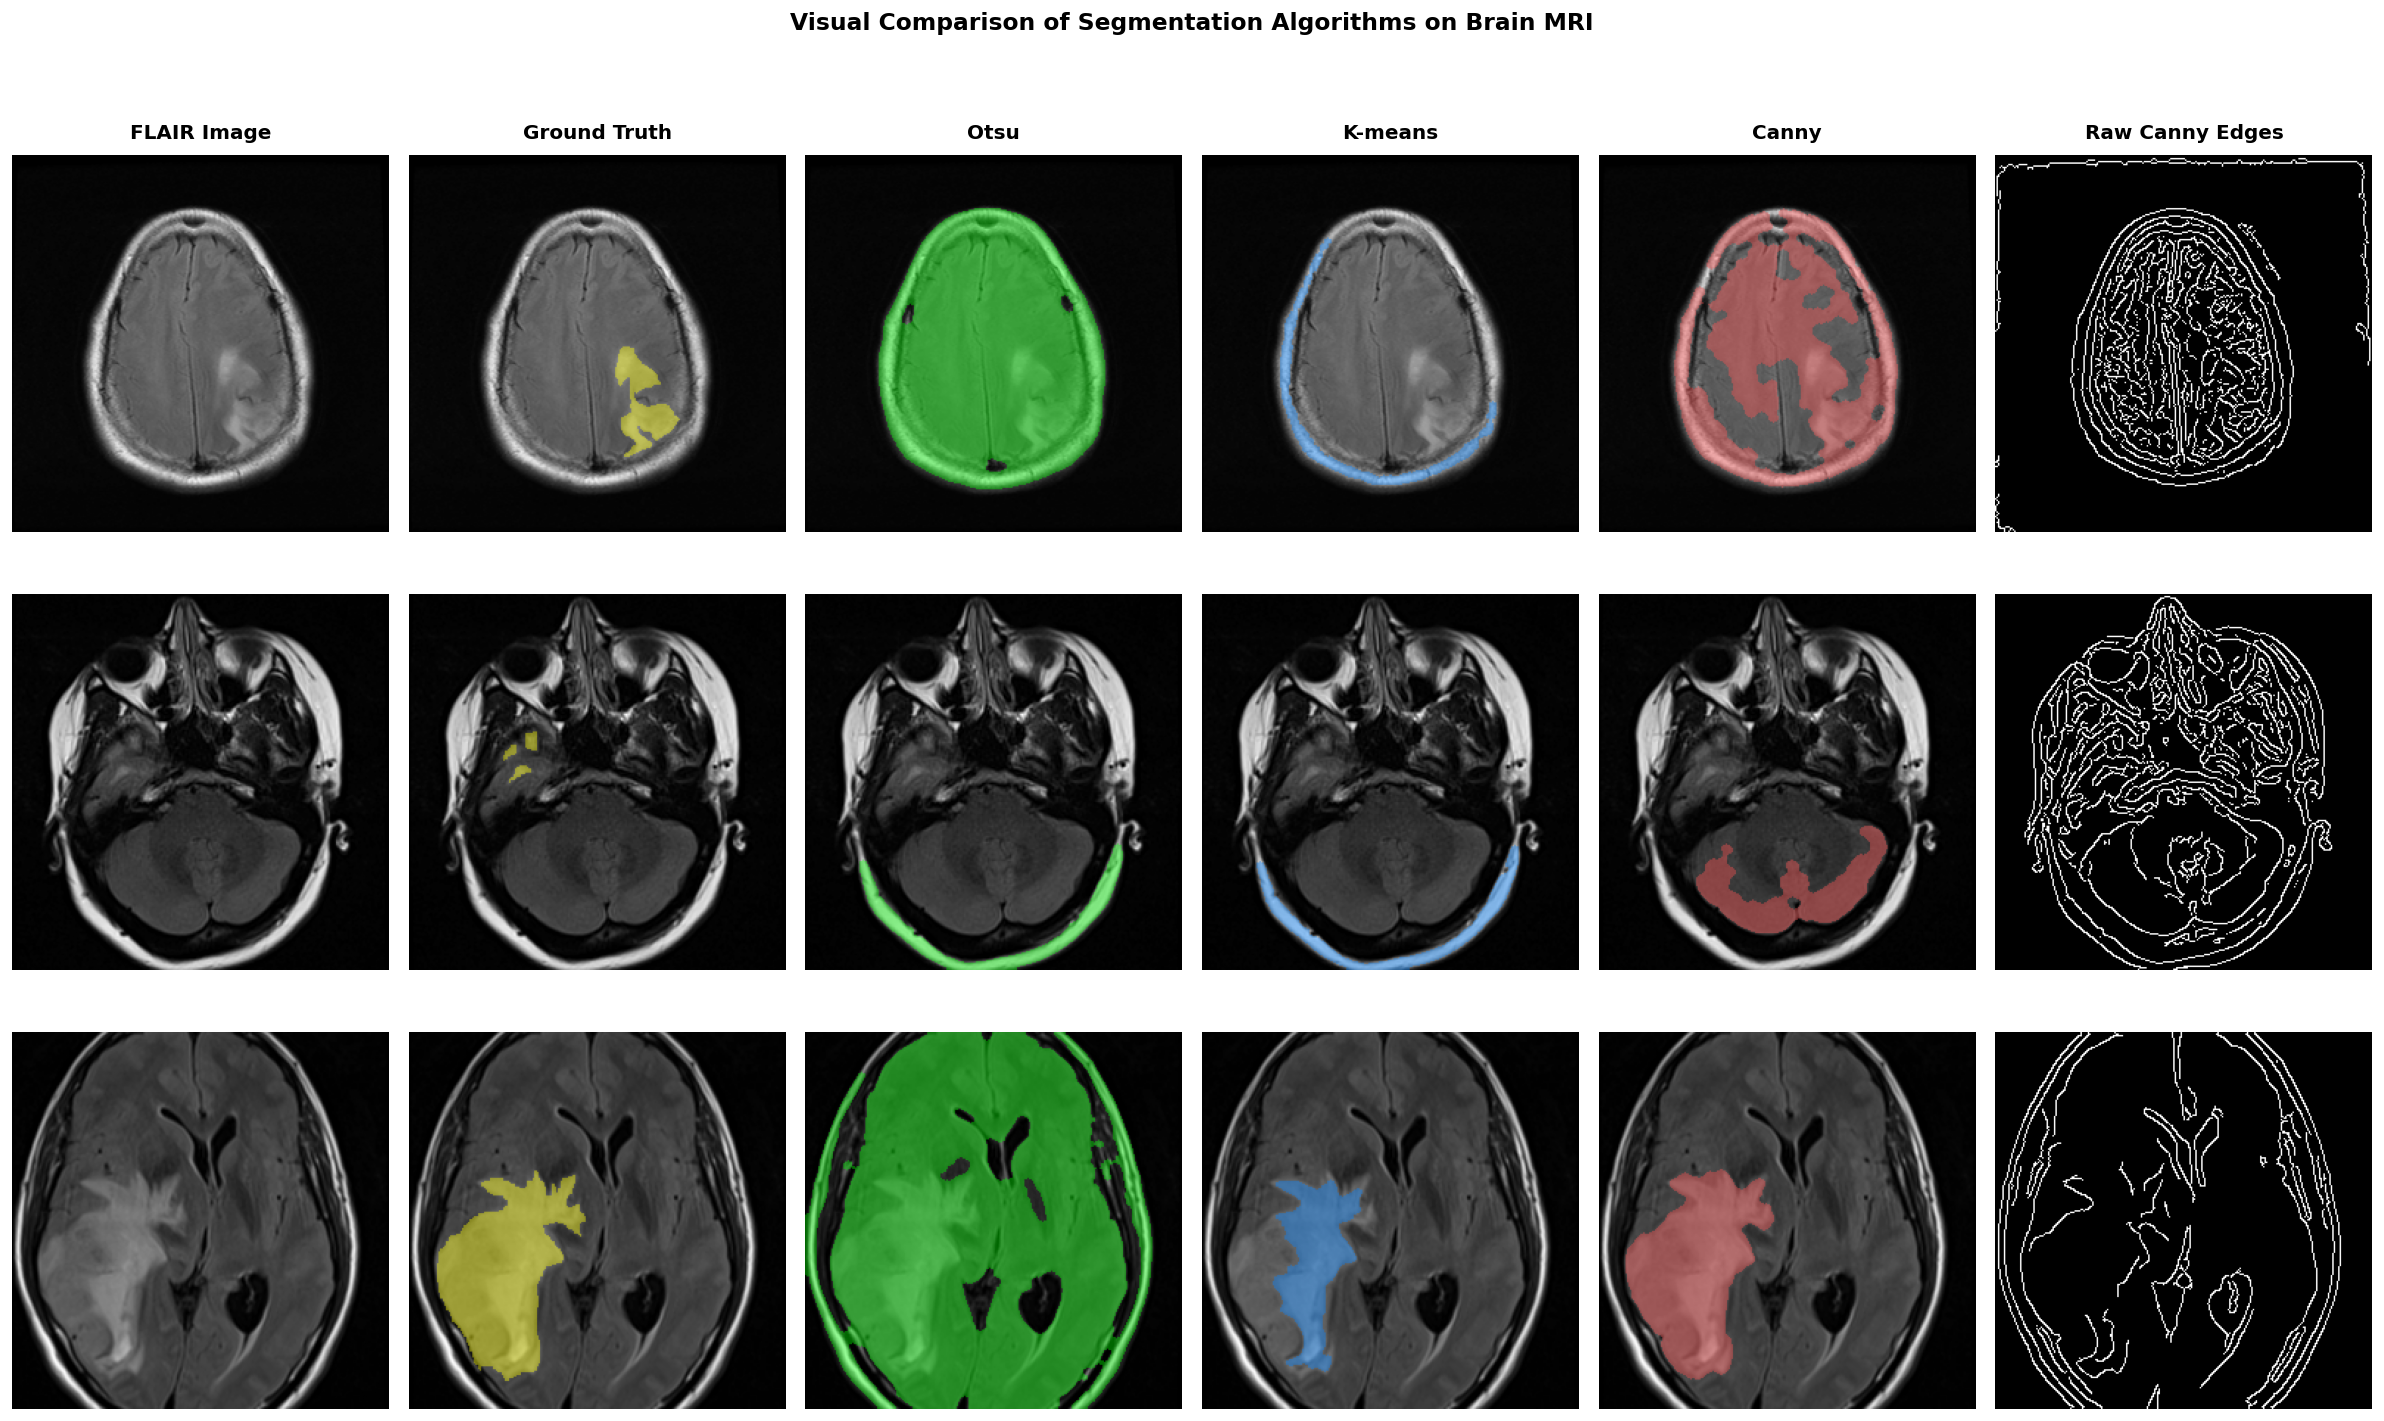

✅ Saved: segmentation_visual_comparison.png


In [10]:
def overlay_mask(flair_img, mask, color=(0, 255, 0), alpha=0.4):
    """Overlay a binary mask on top of a grayscale image with a given color."""
    rgb = cv2.cvtColor(flair_img, cv2.COLOR_GRAY2RGB)
    overlay = rgb.copy()
    overlay[mask == 1] = color
    return cv2.addWeighted(rgb, 1 - alpha, overlay, alpha, 0)

# Display 3 random samples side by side
N_SHOW = 3
fig, axes = plt.subplots(N_SHOW, 6, figsize=(20, N_SHOW * 4))

col_titles = ['FLAIR Image', 'Ground Truth', 'Otsu', 'K-means', 'Canny', 'Raw Canny Edges']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=10)

sample_indices = np.random.choice(len(selected_pairs), N_SHOW, replace=False)

for row, idx in enumerate(sample_indices):
    img_path, msk_path = selected_pairs[idx]
    _, flair   = preprocess_image(img_path)
    gt_mask    = preprocess_mask(msk_path)
    otsu_pred, _ = segment_otsu(flair)
    km_pred,   _ = segment_kmeans(flair)
    canny_pred, edges = segment_canny(flair)

    # Column 0: Original FLAIR image
    axes[row, 0].imshow(flair, cmap='gray')
    axes[row, 0].axis('off')

    # Column 1: Ground Truth (yellow overlay)
    axes[row, 1].imshow(overlay_mask(flair, gt_mask, color=(255, 255, 0)))
    axes[row, 1].axis('off')

    # Column 2: Otsu result (green overlay)
    axes[row, 2].imshow(overlay_mask(flair, otsu_pred, color=(0, 255, 0)))
    axes[row, 2].set_xlabel(f"Dice={compute_metrics(otsu_pred, gt_mask)['Dice']:.3f}  IoU={compute_metrics(otsu_pred, gt_mask)['IoU']:.3f}", fontsize=9)
    axes[row, 2].axis('off')

    # Column 3: K-means result (blue overlay)
    axes[row, 3].imshow(overlay_mask(flair, km_pred, color=(0, 128, 255)))
    axes[row, 3].set_xlabel(f"Dice={compute_metrics(km_pred, gt_mask)['Dice']:.3f}  IoU={compute_metrics(km_pred, gt_mask)['IoU']:.3f}", fontsize=9)
    axes[row, 3].axis('off')

    # Column 4: Canny result (red overlay)
    axes[row, 4].imshow(overlay_mask(flair, canny_pred, color=(255, 80, 80)))
    axes[row, 4].set_xlabel(f"Dice={compute_metrics(canny_pred, gt_mask)['Dice']:.3f}  IoU={compute_metrics(canny_pred, gt_mask)['IoU']:.3f}", fontsize=9)
    axes[row, 4].axis('off')

    # Column 5: Raw Canny edge map
    axes[row, 5].imshow(edges, cmap='gray')
    axes[row, 5].axis('off')

plt.suptitle('Visual Comparison of Segmentation Algorithms on Brain MRI',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('segmentation_visual_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: segmentation_visual_comparison.png')

## 8. Metrics Comparison Charts

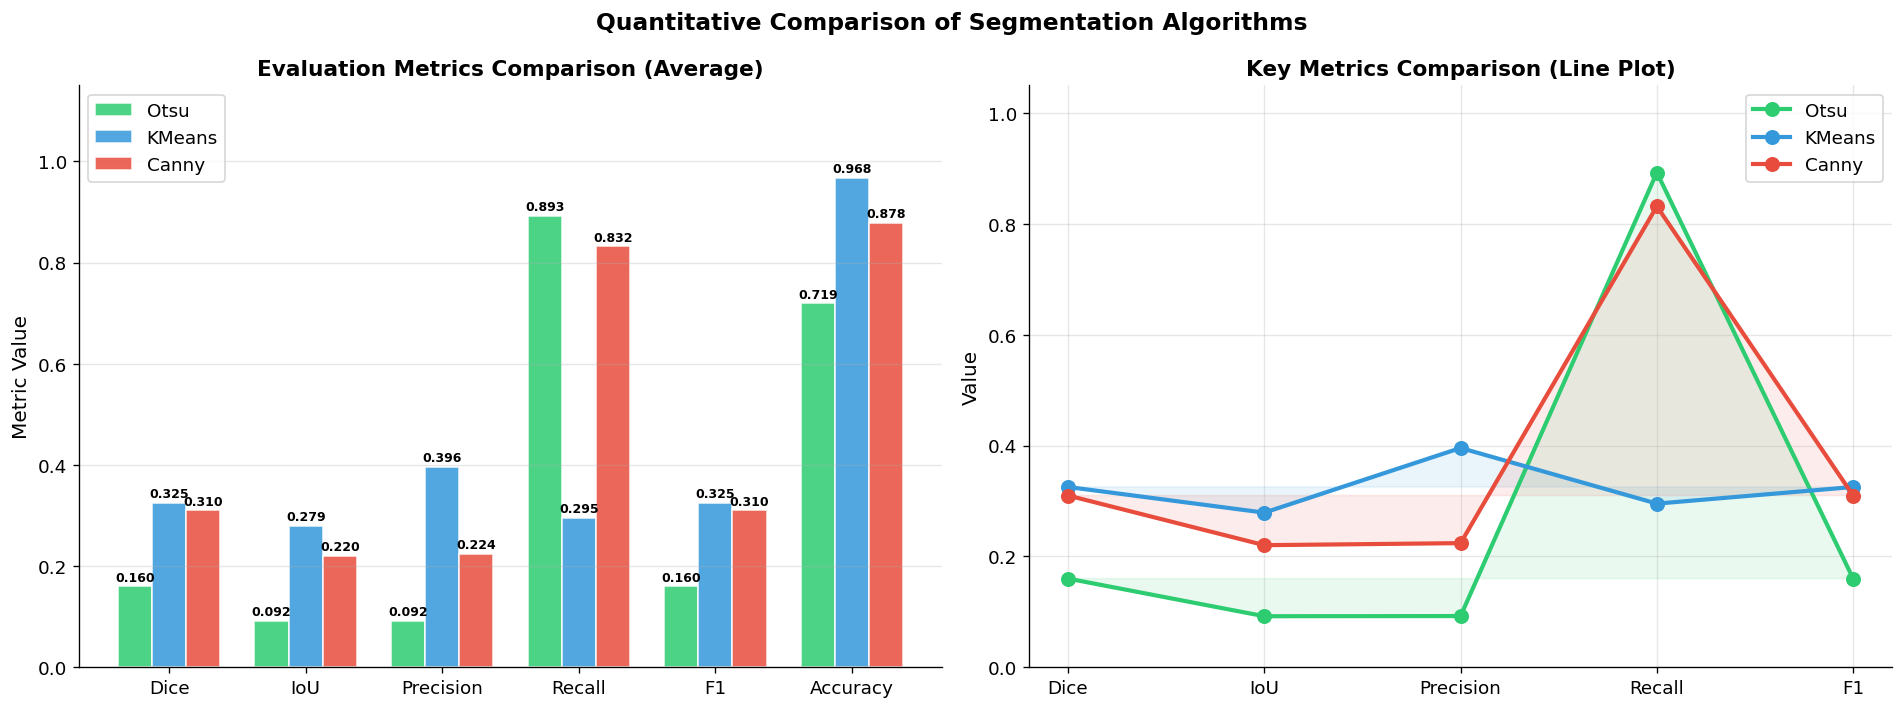

✅ Saved: metrics_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

algos  = list(df_results.index)
colors = ['#2ecc71', '#3498db', '#e74c3c']
x      = np.arange(len(metrics_list))
width  = 0.25

# Chart 1: Grouped Bar Chart for all metrics
ax = axes[0]
for i, (algo, color) in enumerate(zip(algos, colors)):
    vals = [df_results.loc[algo, m] for m in metrics_list]
    bars = ax.bar(x + i * width, vals, width, label=algo, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Evaluation Metrics Comparison (Average)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Chart 2: Line plot for key metrics
ax2 = axes[1]
key_metrics = ['Dice', 'IoU', 'Precision', 'Recall', 'F1']
for algo, color in zip(algos, colors):
    vals = [df_results.loc[algo, m] for m in key_metrics]
    ax2.plot(key_metrics, vals, marker='o', linewidth=2.5, markersize=8, label=algo, color=color)
    ax2.fill(key_metrics, vals, alpha=0.1, color=color)

ax2.set_ylim(0, 1.05)
ax2.set_title('Key Metrics Comparison (Line Plot)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Value', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Quantitative Comparison of Segmentation Algorithms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: metrics_comparison.png')

## 9. Final Results Table

In [12]:
print('=' * 65)
print('      Final Results — Average Across All Samples')
print('=' * 65)
print(df_results.to_string())
print('=' * 65)

# Print the best algorithm for each metric
print('\n🏆 Best algorithm per metric:')
for m in metrics_list:
    best = df_results[m].idxmax()
    val  = df_results[m].max()
    print(f'  {m:10s}: {best} ({val:.4f})')

      Final Results — Average Across All Samples
          Dice     IoU  Precision  Recall      F1  Accuracy
Otsu    0.1601  0.0922     0.0925  0.8928  0.1601    0.7194
KMeans  0.3254  0.2791     0.3958  0.2954  0.3254    0.9675
Canny   0.3100  0.2204     0.2241  0.8318  0.3100    0.8777

🏆 Best algorithm per metric:
  Dice      : KMeans (0.3254)
  IoU       : KMeans (0.2791)
  Precision : KMeans (0.3958)
  Recall    : Otsu (0.8928)
  F1        : KMeans (0.3254)
  Accuracy  : KMeans (0.9675)


## 10. Conclusion & Analysis

### Summary:

| Algorithm | Strengths | Weaknesses |
|---|---|---|
| **Otsu Thresholding** | Fast, simple, no manual parameter tuning | Assumes bimodal histogram; struggles with complex intensity distributions |
| **K-means Clustering** | Flexible, handles multiple intensity groups | Slower, non-deterministic (sensitive to initialization) |
| **Canny + Post-proc** | Precise boundary detection | Requires threshold tuning, sensitive to noise, needs extensive post-processing for solid masks |

### Key Observations:
- In brain FLAIR MRI, tumors appear **hyperintense** (brighter) compared to normal tissue
- Otsu finds a good global threshold but tends to segment all bright regions, not just the tumor
- K-means with k=3 better separates tumor from other bright regions (e.g., skull, ventricles)
- Canny excels at visualizing boundaries but requires heavy post-processing to produce filled masks for Dice/IoU computation

### Future Work:
- Apply deep learning models such as **U-Net** for significantly improved segmentation accuracy
- Explore **ensemble methods** combining multiple classical algorithms
- Tune algorithm parameters per tumor type (glioma, meningioma, pituitary)